# Bernstein–Vazirani algoritmus

In [2]:
# Alap importok
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import time
import random

simulator = AerSimulator()

### 1. Kis példa: n = 3, rejtett vektor s = '101' (bináris) (órai kód)

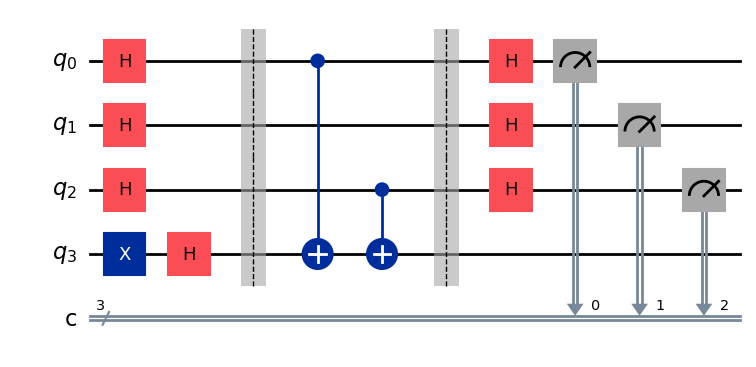

Mérési eredmények: {'101': 1024}


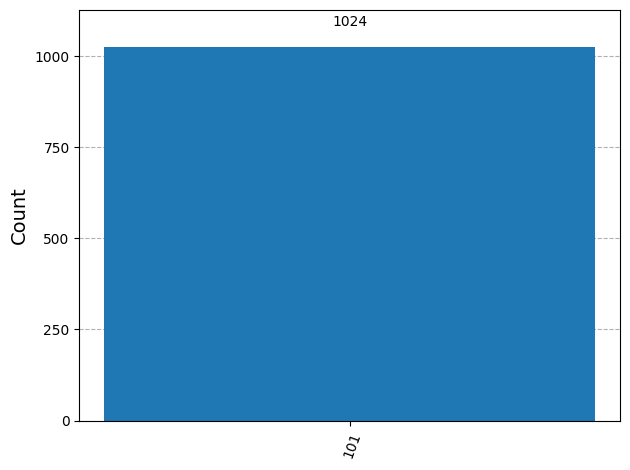

In [3]:
n = 3
secret_string = '101'   # Rejtett bitvektor (s)

qc = QuantumCircuit(n+1, n)   # n bemeneti qubit + 1 segédqubit + n klasszikus bit

# Inicializálás: minden bemeneti qubit |+⟩ állapotba (Hadamard)
for i in range(n):
    qc.h(i)

# Segédqubit |−⟩ állapotba (X majd H)
qc.x(n)
qc.h(n)

qc.barrier() # Csak vizuális elválasztás – nem befolyásolja az eredményt

# Orákulum implementációja
for i in range(n):
    if secret_string[i] == '1': 
        qc.cx(i, n)   # ha s_i = 1, akkor CNOT kapu az i-edik adatqubit állapotát összekapscsolja a segédqubittel
                      # i - kontroll/adat qubit amely szuperpozicíóban van
                      # n - segédqubit |-> állapotban van
                      
qc.barrier()

# Hadamard minden bemeneti qubiten (interferencia)
for i in range(n):
    qc.h(i)

# Mérjük a bemeneti qubiteket
qc.measure(range(n), range(n))

display(qc.draw('mpl'))

job = simulator.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()

print("Mérési eredmények:", counts)
plot_histogram(counts)

# Várható: a '101' 100%-ban


## 1. Skálázhatóság vizsgálata
Az órai kód kiterjesztése nagyobb n-re (pl. 5, 8, 12), és a futási idő, a szimuláció erőforrásigényének mérése, megmutatva, hogy a kvantum előny (n klasszikus lekérdezés vs. 1 kvantum lekérdezés) hogyan nő n-nel.

n     | Klasszikus Q  | Kvantum Q  | Kapuszám   | Mélység  | Idő (s)
----------------------------------------------------------------------
3     | 3             | 1          | 13         | 6        | 0.0009
5     | 5             | 1          | 21         | 8        | 0.0007
8     | 8             | 1          | 33         | 11       | 0.0013
12    | 12            | 1          | 49         | 15       | 0.0021


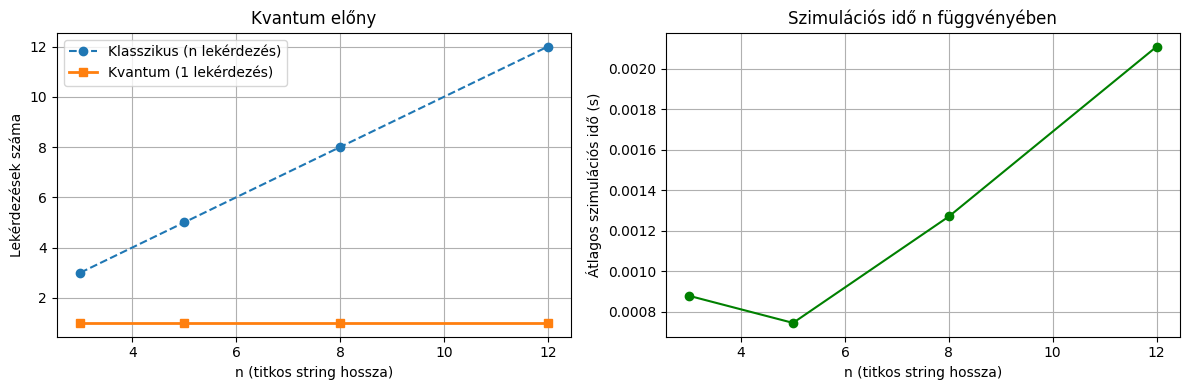

In [4]:
n_values = [3, 5, 8, 12]
futasi_idok = []

print(f"{'n':<5} | {'Klasszikus Q':<13} | {'Kvantum Q':<10} | {'Kapuszám':<10} | {'Mélység':<8} | {'Idő (s)'}")
print("-" * 70)

for test_n in n_values:
    # Áramkör felépítése
    test_s = '1' * test_n
    test_qc = QuantumCircuit(test_n + 1, test_n)
    test_qc.h(range(test_n)) # szuperpozició
    test_qc.x(test_n) # |1>
    test_qc.h(test_n) # |->
    for i in range(test_n):
        if test_s[i] == '1':
            test_qc.cx(i, test_n) # összekapcsolás
    test_qc.h(range(test_n))
    test_qc.measure(range(test_n), range(test_n))

    # Fordítás (a szimulátorhoz optimalizált forma)
    compiled = transpile(test_qc, simulator)

    # Futási idő mérése – 5 futás átlaga, hogy megbízhatóbb legyen
    idok = []
    for _ in range(5):
        start = time.time()
        simulator.run(compiled, shots=1).result()
        idok.append(time.time() - start)
    atlag_ido = sum(idok) / len(idok)
    futasi_idok.append(atlag_ido)

    print(f"{test_n:<5} | {test_n:<13} | {1:<10} | {compiled.size():<10} | {compiled.depth():<8} | {atlag_ido:.4f}")

# Grafikon
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bal: lekérdezések száma
ax1.plot(n_values, n_values, label='Klasszikus (n lekérdezés)', marker='o', linestyle='--')
ax1.plot(n_values, [1]*len(n_values), label='Kvantum (1 lekérdezés)', marker='s', linewidth=2)
ax1.set_xlabel("n (titkos string hossza)")
ax1.set_ylabel("Lekérdezések száma")
ax1.set_title("Kvantum előny")
ax1.legend()
ax1.grid(True)

# Jobb: szimulációs idő
ax2.plot(n_values, futasi_idok, marker='o', color='green')
ax2.set_xlabel("n (titkos string hossza)")
ax2.set_ylabel("Átlagos szimulációs idő (s)")
ax2.set_title("Szimulációs idő n függvényében")
ax2.grid(True)

plt.tight_layout()
plt.show()

## 2. Részleges orákulum: 
Annak vizsgálata, hogy mi az eredmény, ha az orákulum véletlenszerűen kihagyja vagy megfordítja valamelyik CNOT-ot?

Eredeti titkos string : 11111
Hiba: kihagyás a(z) 3. indexnél
Várt eredmény (hibátlan): 11111
Mért eredmény (hibás)   : 10111
Különbség a(z) 3. bitpozícióban látható.


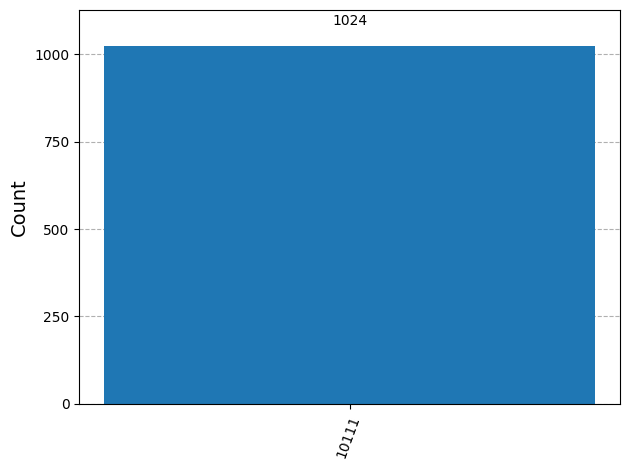

In [5]:
n_p = 5
secret_p = '11111'
hiba_index = random.randint(0, n_p - 1)          # melyik biten lesz hiba
hiba_tipus = random.choice(['kihagyás', 'megfordítás'])  # milyen hiba

print(f"Eredeti titkos string : {secret_p}")
print(f"Hiba: {hiba_tipus} a(z) {hiba_index}. indexnél")

# Áramkör felépítése
qc_p = QuantumCircuit(n_p + 1, n_p)
qc_p.h(range(n_p))
qc_p.x(n_p)
qc_p.h(n_p)
qc_p.barrier()

for i in range(n_p):
    if i == hiba_index:
        if hiba_tipus == 'kihagyás':
            pass  # CNOT kihagyva – az adott bit 0 lesz az eredményben
        else:
            # Megfordítás: CNOT + extra X kapu → az adott bit ellentétes lesz
            qc_p.cx(i, n_p)
            qc_p.x(i)
    elif secret_p[i] == '1':
        qc_p.cx(i, n_p)

qc_p.barrier()
qc_p.h(range(n_p))
qc_p.measure(range(n_p), range(n_p))

counts_p = simulator.run(transpile(qc_p, simulator), shots=1024).result().get_counts()
mert = list(counts_p.keys())[0]

print(f"Várt eredmény (hibátlan): {secret_p}")
print(f"Mért eredmény (hibás)   : {mert}")
print(f"Különbség a(z) {hiba_index}. bitpozícióban látható.")
plot_histogram(counts_p)

## 3. Klasszikus vs. kvantum lekérdezésszám
**Klasszikus megoldás:** 
Összesen `n` lekérdezés szükséges.

**Kvantum megoldás:** Egyetlen lekérdezés elég.

A kvantumelőny demonstrálása a klasszikus megoldás implementálásával és annak összehasonlítása kvantum alapú megoldással (táblázat, grafikon, stb.).

n      | Klasszikus lekérdezés  | Kvantum lekérdezés
--------------------------------------------------
1      | 1                      | 1
5      | 5                      | 1
10     | 10                     | 1
15     | 15                     | 1


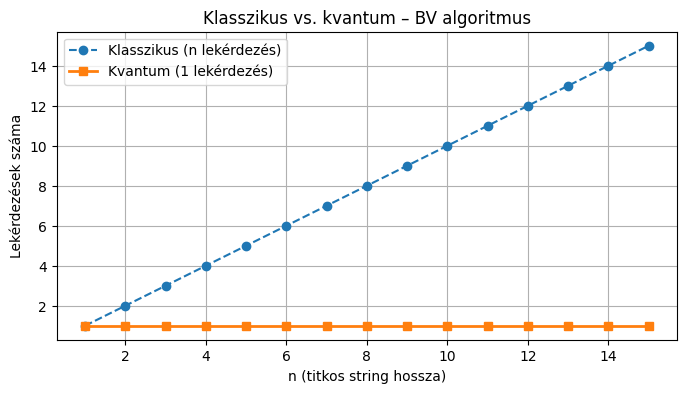

In [6]:
def orakulum(i, secret):
    """Visszaadja a secret i-edik bitjét – ez az egyetlen amit az egységvektor lekérdez."""
    return secret[i]

def klasszikus_bv(secret):
    """Minden bitet egyenként kérdez le – összesen n lekérdezés kell."""
    talalt = ""
    for i in range(len(secret)):
        talalt += orakulum(i, secret)   # lekérdezi az i-edik bitet
    return len(secret), talalt          # (lekérdezések száma, talált string)

# Tesztelés n = 1..15
n_range = list(range(1, 16))
c_lekerd = []
q_lekerd = []

print(f"{'n':<6} | {'Klasszikus lekérdezés':<22} | {'Kvantum lekérdezés'}")
print("-" * 50)
for n in n_range:
    s = '1' * n
    db, talalt = klasszikus_bv(s)
    c_lekerd.append(db)
    q_lekerd.append(1)
    if n in [1, 5, 10, 15]:
        print(f"{n:<6} | {db:<22} | 1")

# Grafikon
plt.figure(figsize=(8, 4))
plt.plot(n_range, c_lekerd, label='Klasszikus (n lekérdezés)', marker='o', linestyle='--')
plt.plot(n_range, q_lekerd, label='Kvantum (1 lekérdezés)', marker='s', linewidth=2)
plt.xlabel("n (titkos string hossza)")
plt.ylabel("Lekérdezések száma")
plt.title("Klasszikus vs. kvantum – BV algoritmus")
plt.legend()
plt.grid(True)
plt.show()